In [15]:
import networkx as nx
import networkit as nk

import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import operator
import itertools
from tqdm import tqdm
import logging



import sys
from pathlib import Path

#Truc moche pour que les imports de src marchent
current_file = Path.cwd()
project_root = current_file.parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from helpers import Count, get_dict, timeit, rx_helper, Base_car_fleet, Car

np.random.seed(1)

ox.__version__

'2.1.0'

### Initial state

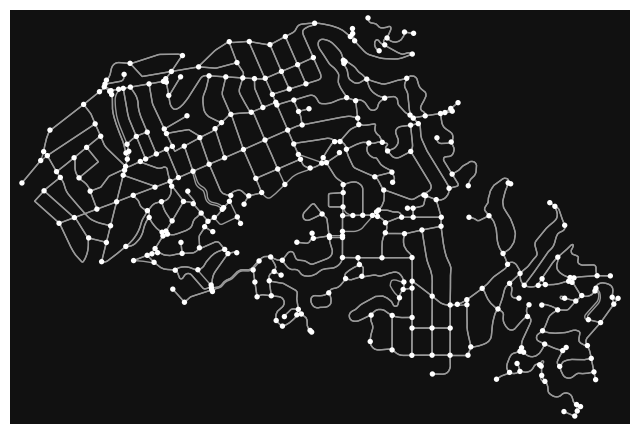

In [16]:
# download/model a street network for some city then visualize it
# G = ox.graph.graph_from_place("Bazas, France", network_type="drive")
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

### Preprocessing

In [17]:
for u,v,k in G.edges:
    attrs_e = {(u, v, k): {
        'demand': 0, 
        'weight': 1, 
        'capacity': np.random.randint(5,10)
        # 'capacity': 1

        }
    }
    nx.set_edge_attributes(G, attrs_e)

for u,v,k in G.edges:
    print(G[u][v][k])
    break

{'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'demand': 0, 'weight': 1, 'capacity': 8}


In [18]:
# G3=ox.convert.to_digraph(G) NOT FOR NOW CAUSE WE SET WEIGHTS=1 or 10000
# G3=nx.DiGraph(G)
G3=G

In [19]:
len(max(list(nx.strongly_connected_components(G3)), key=len))/G3.number_of_nodes()

0.9914772727272727

In [20]:
# Get strongly connected component
G4 = max(list(nx.strongly_connected_components(G3)), key=len)
G4 = G3.subgraph(G4)

### Bla

In [21]:
class Car_fleet(Base_car_fleet):
    def select_min_weight_lane(self, node1, node2, weight):
        """
    In MultiDiGraph, selects the path with minimum weight.
        """   
        lanes=self.graph[node1][node2]

        if self.is_multi:
            selected_id=min(lanes, key=lambda k : lanes[k].get(weight))
            return selected_id, lanes[selected_id]
        else:
            return None, lanes

    def handle_interactions(self, node1, node2, demand_delta, new_weight, op):
        if node1!=node2: # Prevent self-loops from interacting (arrival node for example)
            edge_id, edge=self.select_min_weight_lane(node1, node2, 'weight')
            edge['demand']+=demand_delta
            if op(edge['demand'], edge['capacity']):
                if self.is_multi:
                    self.graph[node1][node2][edge_id]['weight']=new_weight
                else:
                    self.graph[node1][node2]['weight']=new_weight

    def check_edges_along_path(self, path, dist=3):
        edges = []
        for k, (u, v) in enumerate(itertools.pairwise(path), start=1):
            if u == v:
                edges.append(0)
                continue
            
            if k<=dist: 
                _, edge=self.select_min_weight_lane(u,v,'weight')
                edges.append(edge['weight'])
        return edges
    
    def get_paths_to_calculate(self, paths, edges_state:dict, dist=3):
        """
    Returns the paths to recompute, in the form of a tuple (source, target)
    The newly blocked roads within a certain radius are chosen to be recomputed.
        """
        to_calculate=[]
        if dist>len(edges_state):
            dist=len(edges_state)

        for k, path in enumerate(paths):
            s,t = path[0], path[-1]
            edge_state=edges_state[(s,t)]
            if self.check_edges_along_path(path, dist)!=edge_state[:dist] or all(path):
                to_calculate.append((s, t))
                
        return to_calculate

    @timeit
    def display(self, ax, edge_alpha=None, edge_list=None):
        """
    Displays city (self.graph) and traffic (self.fleet).
        """
        node_c = get_dict(list(self.graph.nodes), self.get_loc(include_completed=False), self.get_arr(include_completed=False), 'r', 'g', 'grey')
        node_size = {node:Count(self.get_loc(include_completed=False))[node]**0.5*15 for node in list(self.graph.nodes)}
        if edge_list:
            if self.is_multi:
                edge_c = {(u,v,k):'y' if edge_data['weight']>2 else 'grey' for u,v,k,edge_data in list(self.graph.edges(keys=True,data=True))}
            else:
                edge_c = {(u,v):'y' if edge_data['weight']>2 else 'grey' for u,v,edge_data in list(self.graph.edges(data=True))}
            for edge in self.info:
                edge_c[edge]='r'
            
        ox.plot.plot_graph(
                nx.MultiDiGraph(self.graph),
                ax=ax,          # Use the animation's axis
                show=False,     # Don't open a new window now
                close=False,    # Don't close the plot
                node_color=list(node_c.values()),
                node_size=list(node_size.values()),
                edge_alpha=edge_alpha if edge_alpha else None,
                edge_color=list(edge_c.values()) if edge_c else None
            )
        
    @timeit
    def calculate_paths(self, dist):
        """
    Recomputes car paths if their state within a certain radius have changed.
        """
        unique = set(tuple(item) for item in self.get_paths())
        deduplicated_paths = [list(item) for item in unique]
        to_calculate=self.get_paths_to_calculate(deduplicated_paths, self.edges_state, dist)

        for s,t in to_calculate:
            path = self.get_path(s, t, weight='weight')
            self.edges_state[(s,t)] = self.check_edges_along_path(path)
            self.all_paths[s][t] = [path]

    @timeit
    def update_fleet(self):
        """
    Updates car states and handles interactions during displacement.
        """
        for k,car in enumerate(self.fleet):
            if self.step>0:
                self.handle_interactions(car.old_loc, car.loc, -1, 1, op=operator.lt) # Update old edges
        
            if not car.completed:
                path = self.all_paths[car.loc][car.arr][0]
                cost = self.get_cost(path, 'weight')

                if cost<(actual_cost:=self.get_cost(car.path, 'weight')):
                    car.path=path
                    cost=actual_cost
                
                if actual_cost > 10000:
                    self.info.append((car.path[0], car.path[1]))

                car.update_loc_and_path()
                # On supprime pas l'ancien état puisque deux voitures peuvent se suivre
                self.edges_state[(car.path[0], car.path[-1])]=self.check_edges_along_path(car.path)

                self.handle_interactions(car.old_loc, car.loc, 1, 10000, op=operator.ge) # Update new edges

    def run(self):
        self.info=[]
        if not self.all_completed():

            self.calculate_paths(dist=3)
            self.update_fleet()
            self.step+=1


### Dynamique induite et update

100%|██████████| 90/90 [00:08<00:00, 36.53it/s]

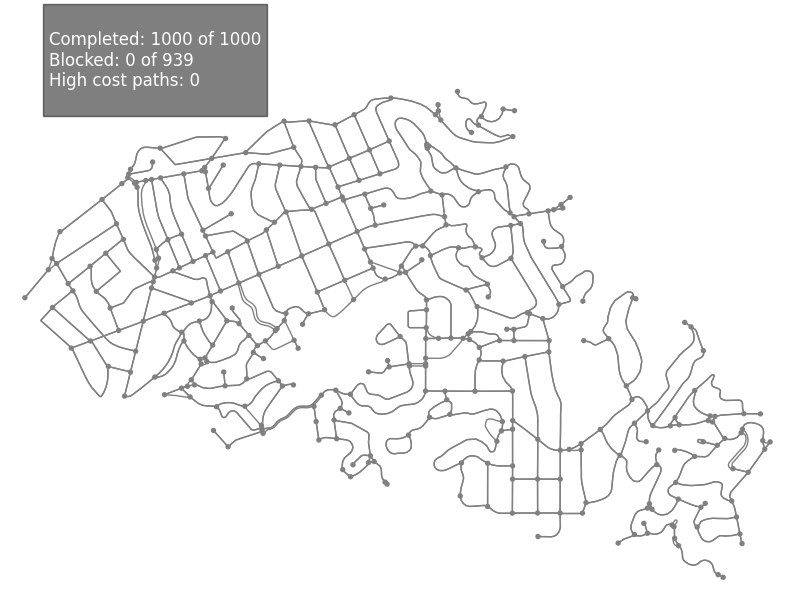

91it [00:12,  7.40it/s]                        


In [23]:
demand=Car_fleet(G4.copy(), size=2*1000, replace=True)
frames=90
logging.info(f'__________________________________________________________________')

def update(frame):
    pbar.update(1)
    if demand.all_completed():
        return ax,
    
    ax.clear()
    if frame > 0:
        demand.run()
    demand.display(ax=ax, edge_list=True)
    string=f'''
Completed: {sum(demand.get_completed())} of {demand.num_cars}
Blocked: {sum(demand.get_edge_blocked().values())} of {demand.graph.number_of_edges()}
High cost paths: {len(demand.info)}
'''
    ax.text(0.05, 0.95, string,
            transform=ax.transAxes, fontsize=12, color='white', 
            bbox=dict(facecolor='black', alpha=0.5))
    return ax,

with tqdm(total=frames) as pbar:
    fig, ax = plt.subplots(figsize=(10, 8))
    ani = FuncAnimation(fig, update, frames=frames, interval=150, repeat=False)
    ani.save("ani.gif", writer='pillow')
    plt.show()